# এটাকে আমরা normally continues numerical dataset এর জন্য use করি

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


plt.rcParams['figure.figsize']=(7, 4)

In [4]:
# load and inspect the dataset
data= load_breast_cancer()
X= data.data
y= data.target

print('Shape of X: ',X.shape)
print('Shape of y: ',y.shape)
print('Target names: ',data.target_names)
print('\nFirst 4 feature names: ',data.feature_names[:5])

Shape of X:  (569, 30)
Shape of y:  (569,)
Target names:  ['malignant' 'benign']

First 4 feature names:  ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']


In [5]:
df= pd.DataFrame(X, columns=data.feature_names)
df['target']=y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


target
1    357
0    212
Name: count, dtype: int64


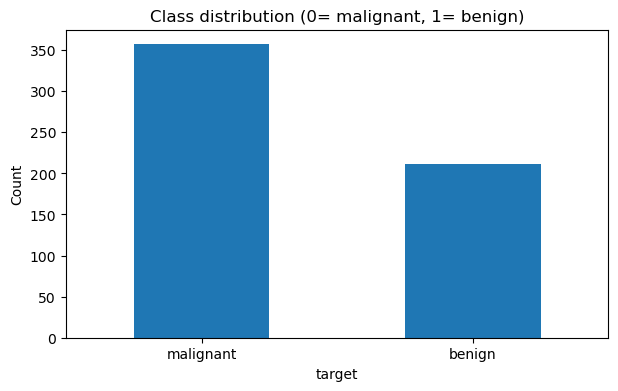

In [8]:
# class Distribution
class_counts= df['target'].value_counts()
print(class_counts)

plt.figure()
class_counts.plot(kind='bar')
plt.xticks(ticks=[0, 1], labels=data.target_names, rotation=0)
plt.title('Class distribution (0= malignant, 1= benign)')
plt.ylabel('Count')
plt.show()

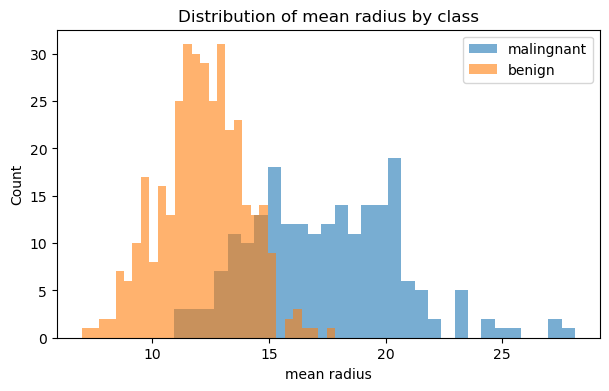

In [9]:
# feature visualization
feature_name= 'mean radius'
feat_idx= list(data.feature_names).index(feature_name)

plt.Figure()
plt.hist(X[y==0][:, feat_idx], bins=30, alpha=0.6, label='malingnant')
plt.hist(X[y==1][:, feat_idx], bins=30, alpha=0.6, label='benign')
plt.legend()
plt.xlabel(feature_name)
plt.ylabel('Count')
plt.title(f'Distribution of {feature_name} by class')
plt.show()

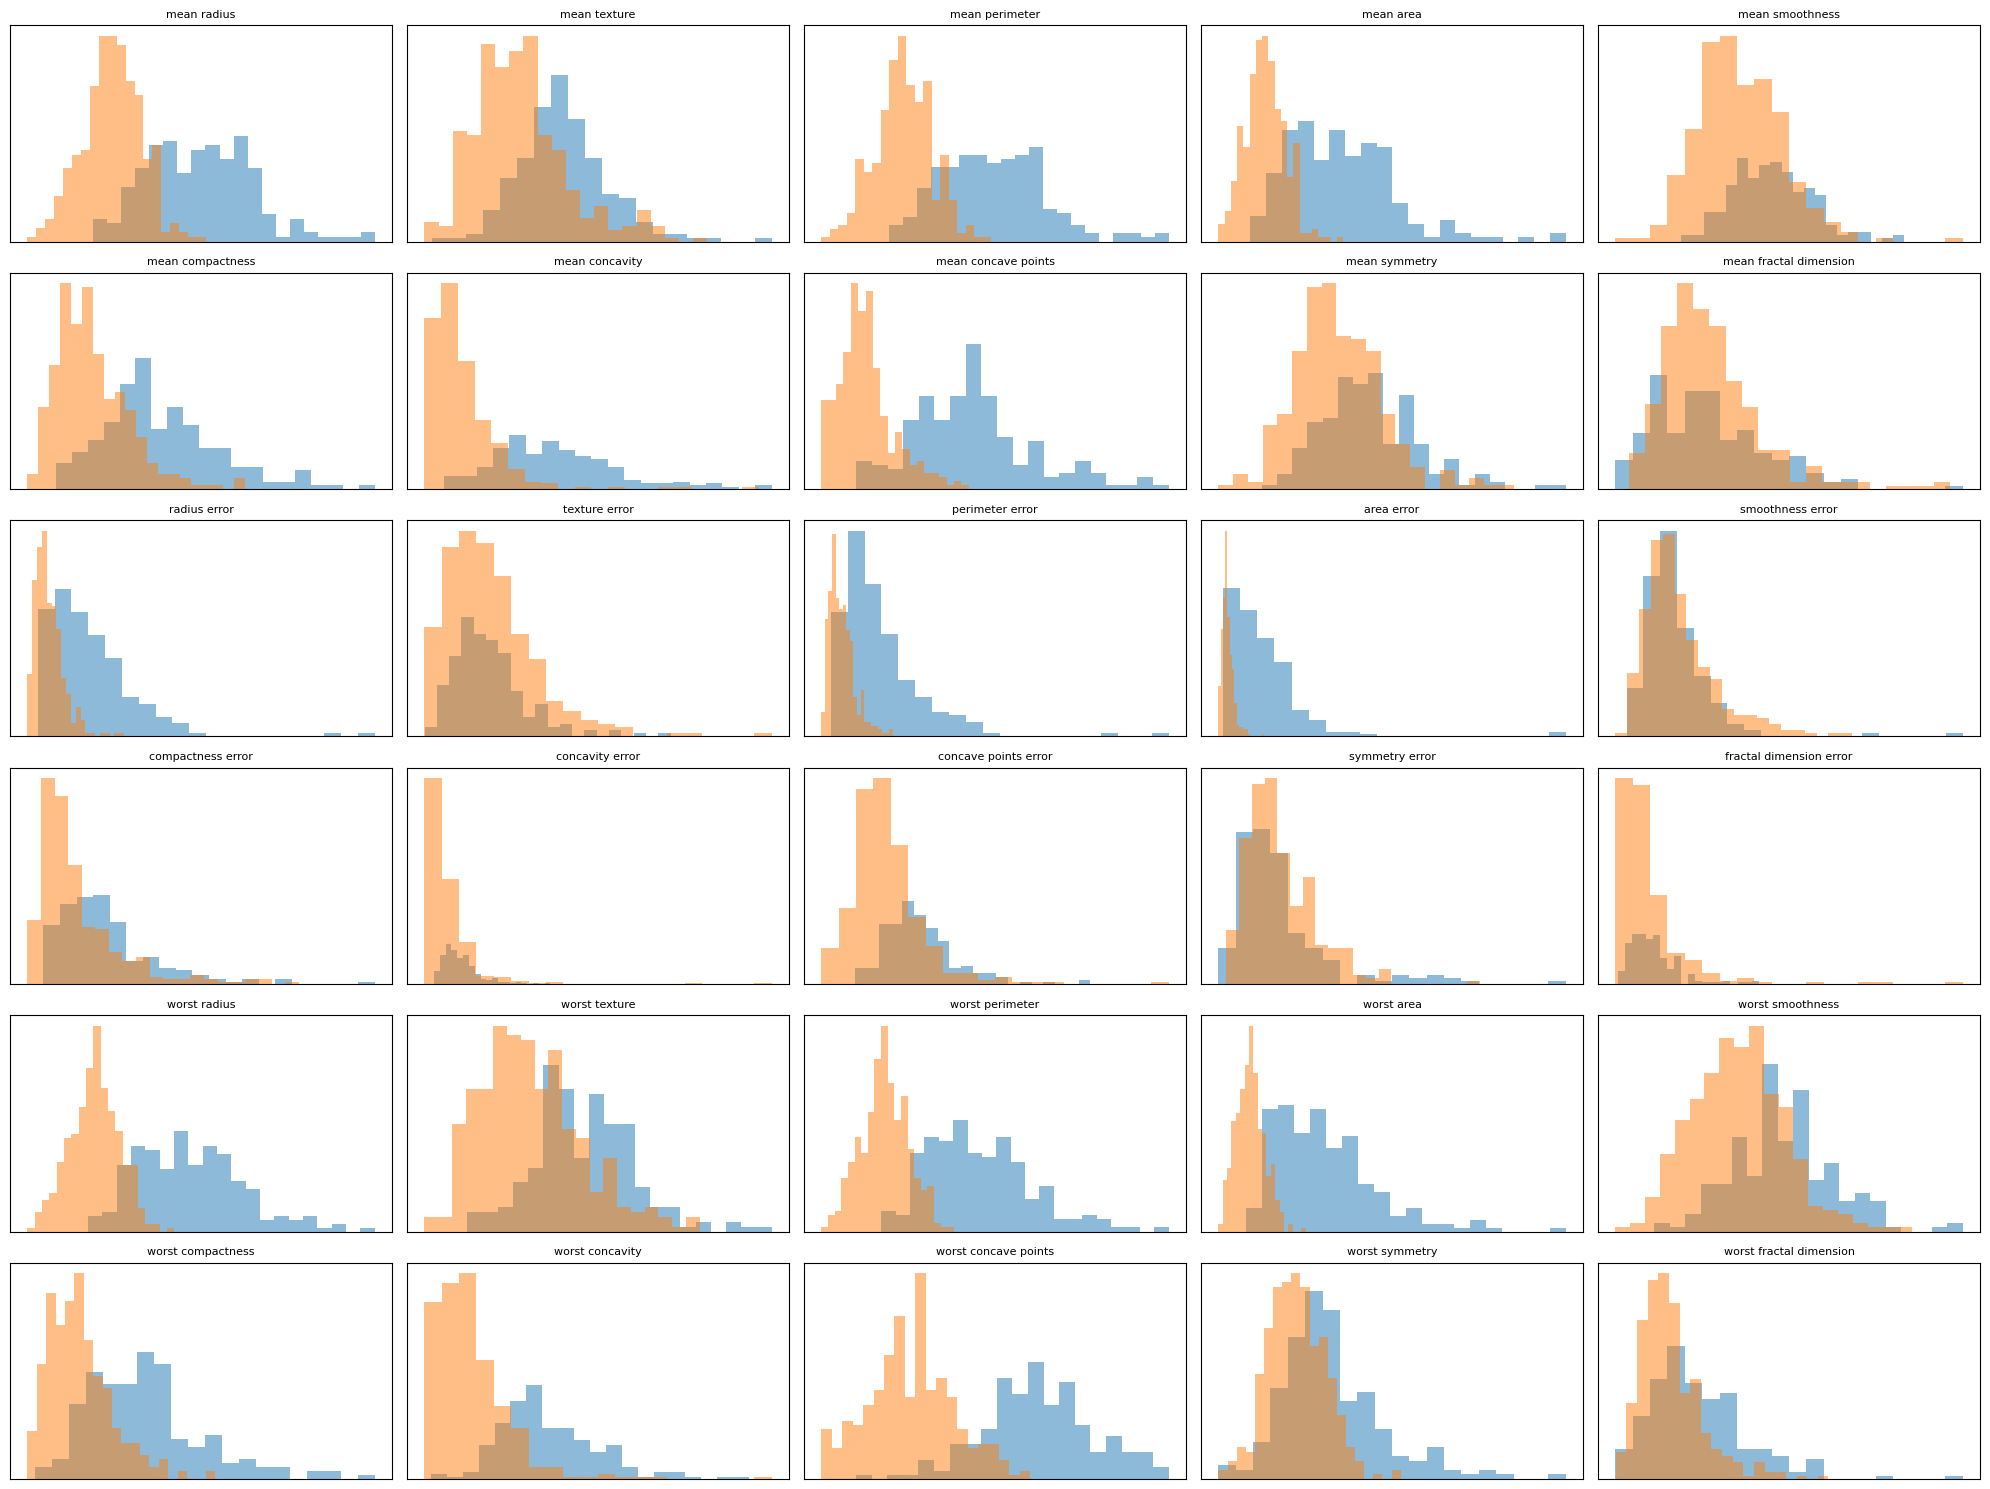

In [11]:
feature_names = data.feature_names

plt.figure(figsize=(20, 15))

for i, feature_name in enumerate(feature_names):
    plt.subplot(6, 5, i+1)  # adjust rows/cols if needed

    plt.hist(X[y==0][:, i], bins=20, alpha=0.5)
    plt.hist(X[y==1][:, i], bins=20, alpha=0.5)

    plt.title(feature_name, fontsize=8)
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

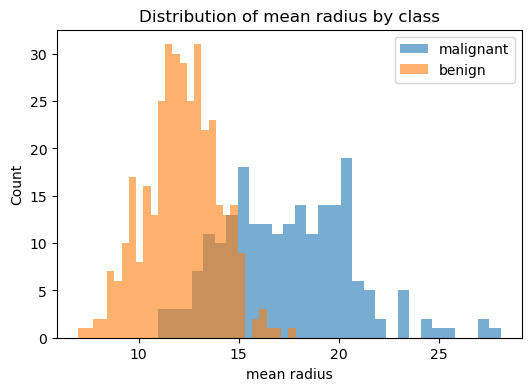

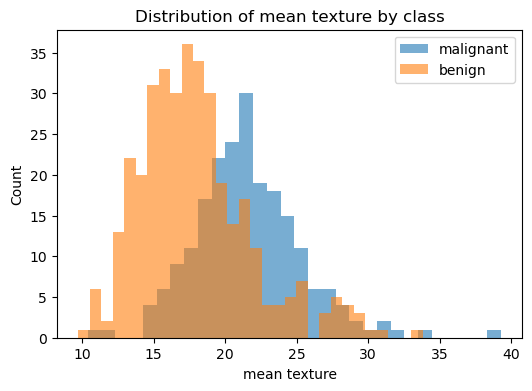

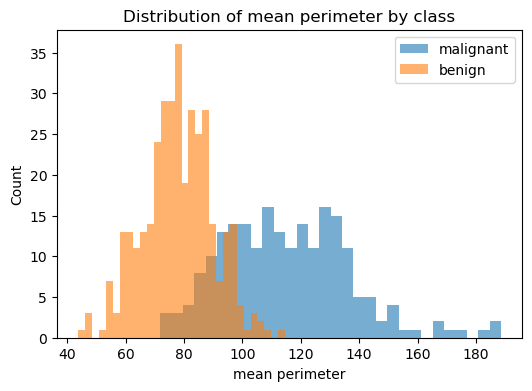

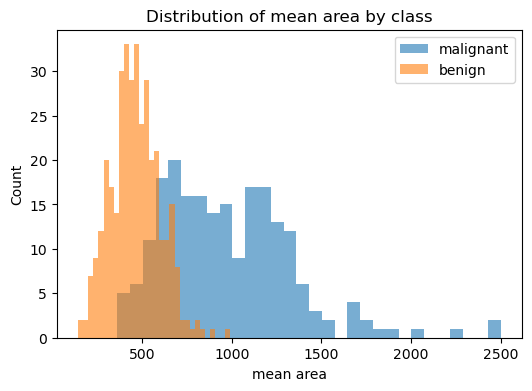

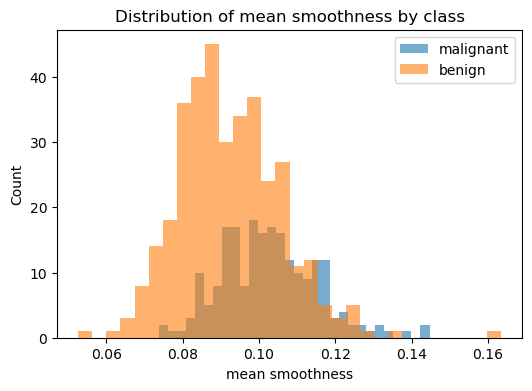

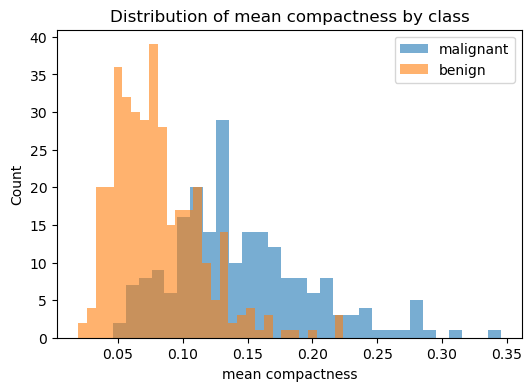

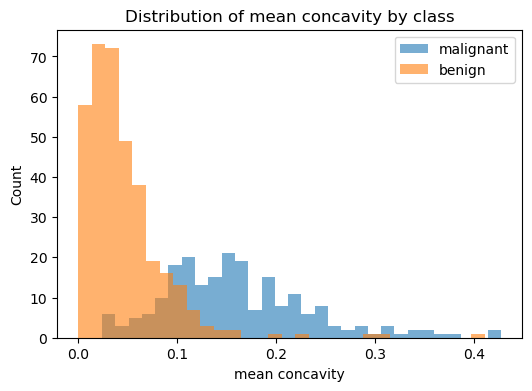

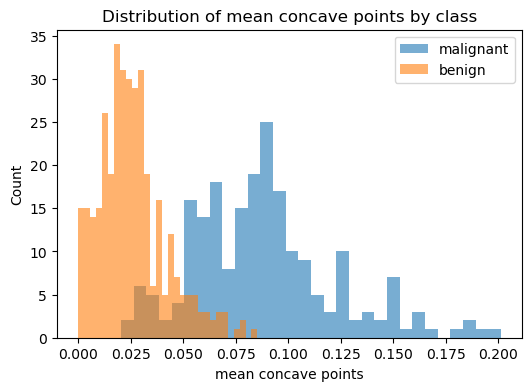

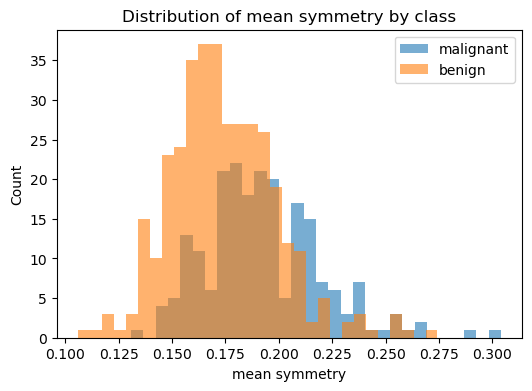

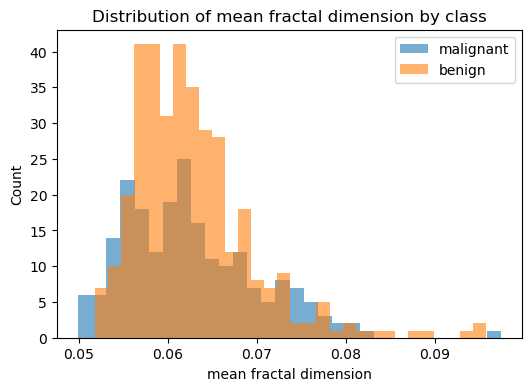

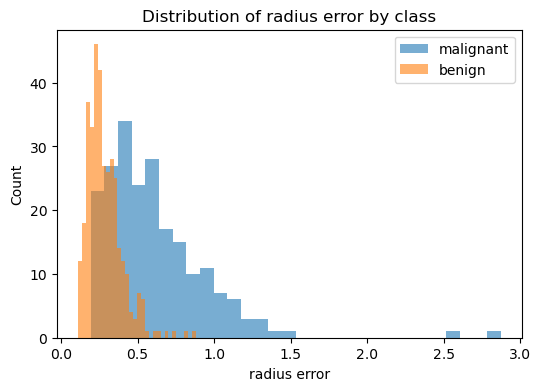

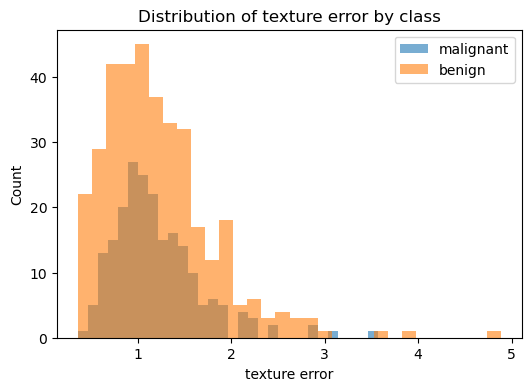

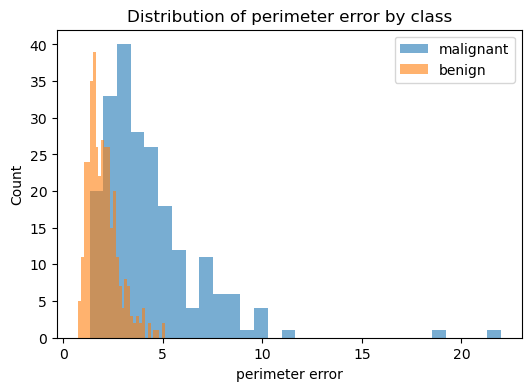

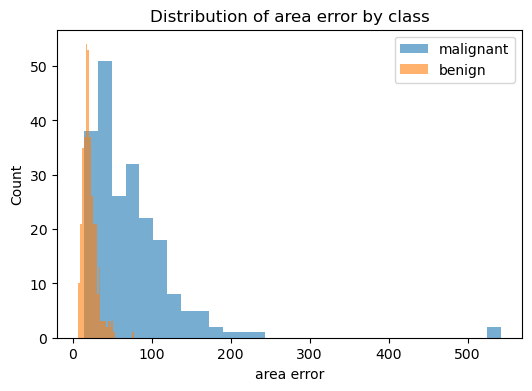

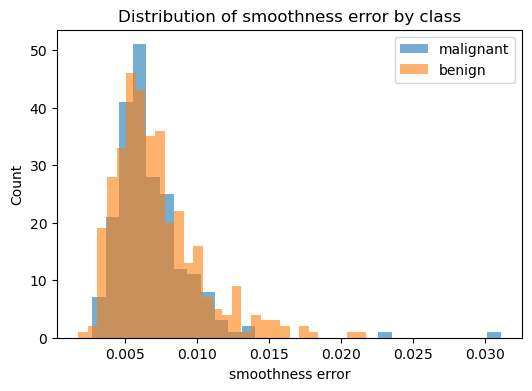

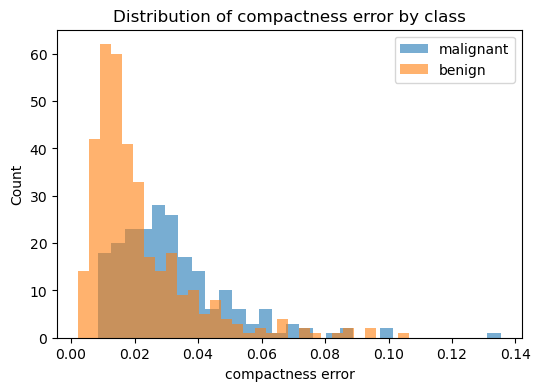

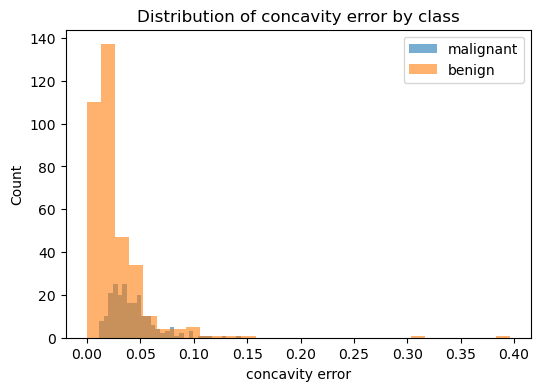

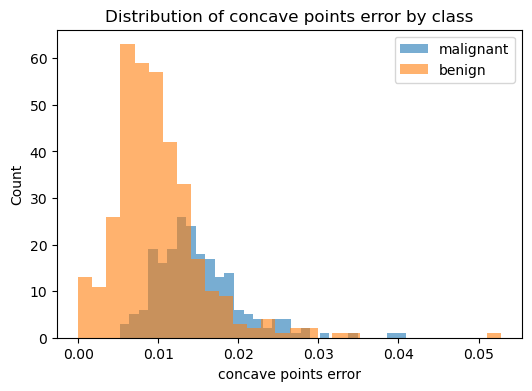

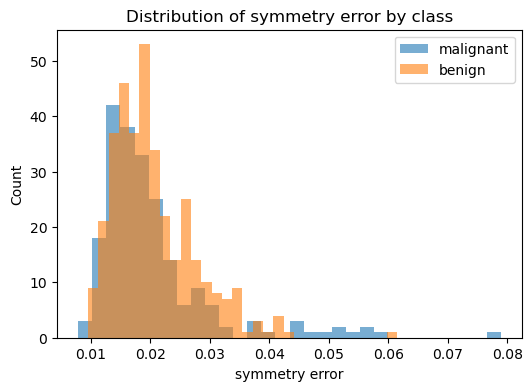

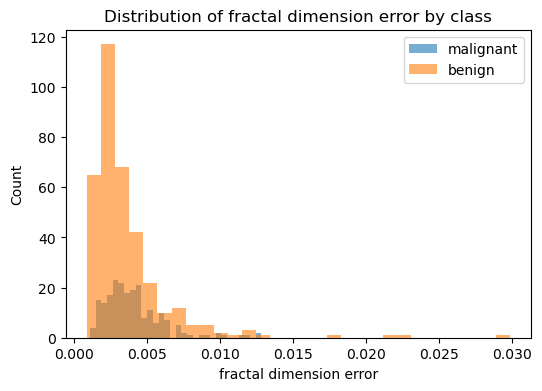

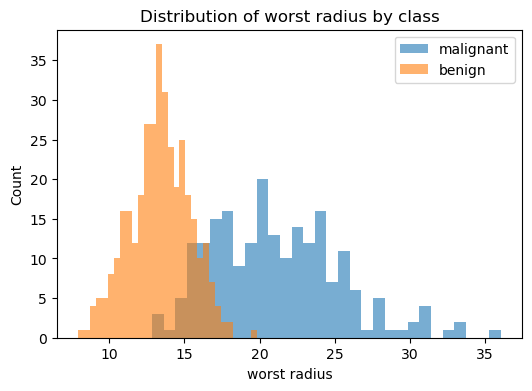

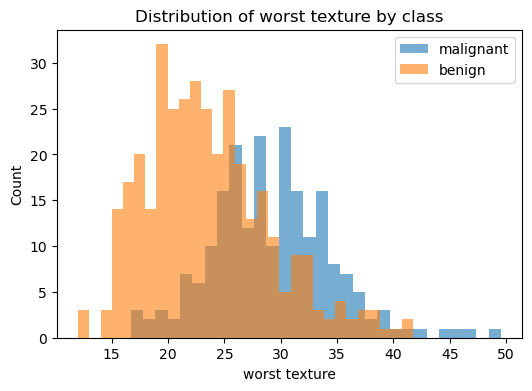

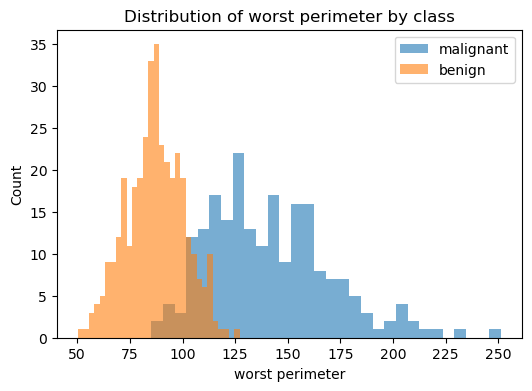

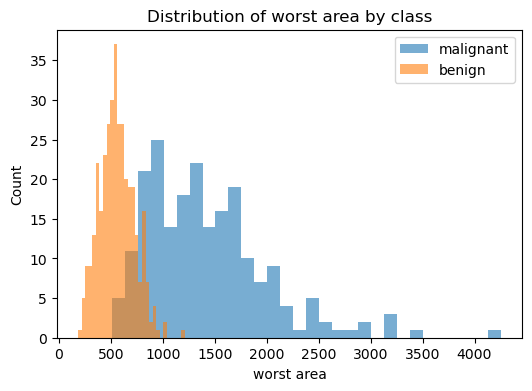

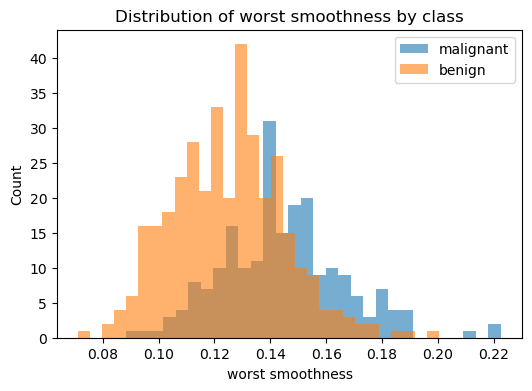

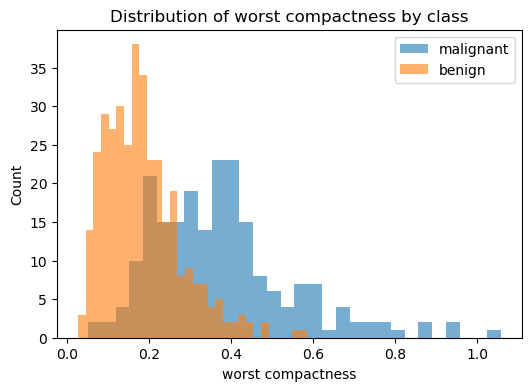

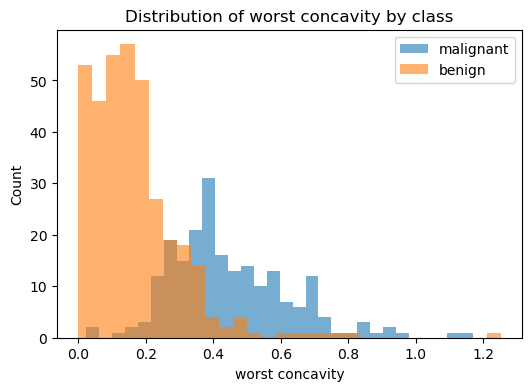

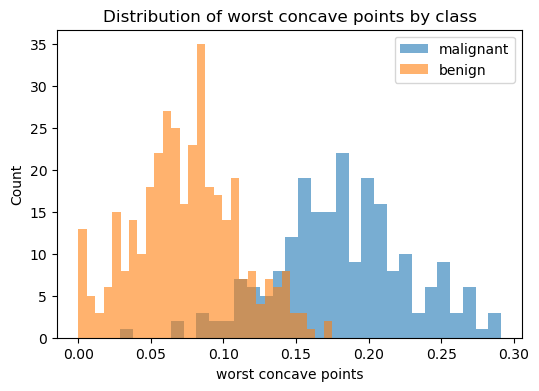

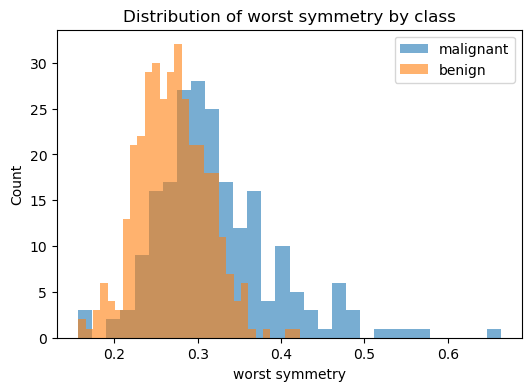

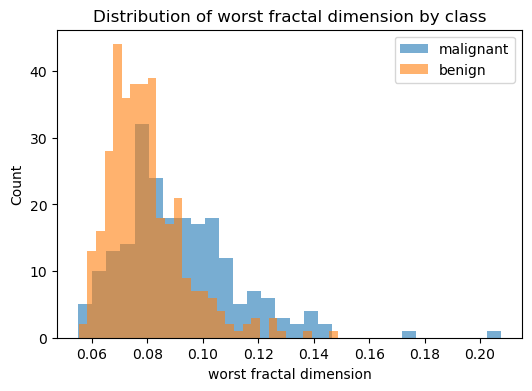

In [12]:
feature_names = data.feature_names

for i, feature_name in enumerate(feature_names):
    plt.figure(figsize=(6,4))

    plt.hist(X[y==0][:, i], bins=30, alpha=0.6, label='malignant')
    plt.hist(X[y==1][:, i], bins=30, alpha=0.6, label='benign')

    plt.legend()
    plt.xlabel(feature_name)
    plt.ylabel('Count')
    plt.title(f'Distribution of {feature_name} by class')
    plt.show()

In [13]:
# train test split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.25, random_state=42, stratify=y) # এখানে stratify use করলে প্রতিটা class থেকে indivisually test_size=0.25 বা যা দেয়া হবে, ওই টুকু আলাদা আলাদা ভাবে নিবে।যার ফলে প্রতি কাজ থেকে সমান ভাবে শিখতে পারবে। কোন ক্লাস থেকে বেশি কম হবে না

X_train.shape, X_test.shape

((426, 30), (143, 30))

In [14]:
gnb= GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

In [15]:
y_pred= gnb.predict(X_test)
acc= accuracy_score(y_test, y_pred)

acc

0.9370629370629371

Confusion matrix
 [[46  7]
 [ 2 88]]


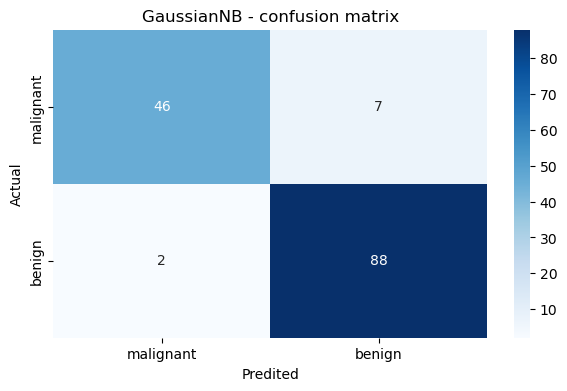

In [17]:
# confusion matrix
cm= confusion_matrix(y_test, y_pred)
print('Confusion matrix\n', cm)


sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=data.target_names,
    yticklabels=data.target_names)
plt.xlabel('Predited')
plt.ylabel('Actual')
plt.title('GaussianNB - confusion matrix')
plt.show()

In [20]:
# classification report
print(classification_report(y_test, y_pred, target_names=data.target_names)) # target names দিয়ে দিলে 1,2 এর পরিবর্তে 1,2 এর আসল যে নাম সেটা দেখাবে

              precision    recall  f1-score   support

   malignant       0.96      0.87      0.91        53
      benign       0.93      0.98      0.95        90

    accuracy                           0.94       143
   macro avg       0.94      0.92      0.93       143
weighted avg       0.94      0.94      0.94       143

